In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
import sys
import sklearn
print(sklearn.__version__)
import warnings
# Suppress all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

1.3.2


In [2]:
genetic = pd.read_csv("Expression_log2_21_primaryNivo_braun_2020.csv",index_col=0)
genetic

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,33.26816,30.04056,30.36292,30.98129,32.38442,28.01561,31.24379,33.81903,33.22469,31.23383
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,31.53633,29.94062,30.80829,30.74475,32.09470,26.32526,32.70057,33.67262,33.10198,32.44643
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,30.74474,31.95812,30.73898,30.15898,31.69473,26.33098,32.68330,33.96047,32.97135,32.20607
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,31.63196,30.71732,31.09654,30.25757,31.90774,27.53819,32.64194,34.54254,33.24885,32.78278
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,26.915750,22.999432,23.219176,38.931987,22.705126,22.869853,21.076515,21.271282,21.807184,31.447751,...,31.75620,30.75149,30.55896,30.17101,31.01545,21.45312,32.86620,34.24375,34.86720,32.73361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,28.60179,30.27215,31.08287,31.21266,33.18573,29.26041,31.70839,32.97611,34.23396,32.87393
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,26.14211,31.31652,31.24066,31.34713,33.06662,27.08693,30.62278,35.10264,33.68084,30.73622
P66425-03B-Run1_S10_L001,30.099518,25.040893,33.891608,38.289830,21.357557,26.870362,20.980667,20.992693,21.018133,33.654328,...,32.54706,29.97152,31.22229,30.38211,31.30604,27.29504,32.44263,34.20699,32.80918,32.29759


In [3]:
cl = pd.read_csv("braun_data_clinical_data.csv",index_col=0)
dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]

/tmp/ipykernel_3256155/3204985976.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]


In [4]:
dfmerge = pd.merge(genetic.reset_index(),cl.reset_index(),how='left', left_on="gene_name", right_on="RNA_ID")
dfmerge.shape

(133, 20561)

In [5]:
modelinput_expr = genetic.loc[dfcl.index.tolist()]
print(modelinput_expr.shape)
modeltarget_expr = dfcl["Benefit"].replace("NCB",0).replace("CB",1).tolist()

(90, 20545)


# network features input are avaiable:

In [6]:
edges_read = pd.read_csv("primaryNivo_common_edges_adjusted+var10000.txt",index_col=0)

edges_selected = edges_read.copy()
edges_input = edges_selected.loc[modelinput_expr.index,:]

# combination of gene expression and gene coexpression

In [7]:
modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges')

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,HSD3B7_USP34,STK11_TAB2,ITCH_TUBGCP6,NIPBL_TGFB1,ETAA1_LRCH4,EIF3E_IL11RA,CCDC142_CSDE1,CCNL2_NEDD1,RPL37_STK11,ACTR2_ATG16L2
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.507149,-0.625087,-0.550042,-0.545841,-0.492360,-0.520370
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,-0.535085,-0.651356,-0.529483,-0.585138,-0.507149,-0.519079,-0.550042,-0.479363,-0.492360,-0.520370
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,-0.642597,-0.548588,-0.476628,-0.585138,-0.635350,-0.519079,-0.550042,-0.537486,-0.594656,-0.520370
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,-0.642597,-0.548588,-0.594918,-0.585138,-0.561262,-0.519079,-0.550042,-0.543265,-0.594656,-0.623699
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,30.731451,22.999432,25.282264,37.915010,22.705126,28.859039,21.076515,21.271282,21.807184,31.851192,...,-0.535085,-0.651356,-0.476628,-0.585138,-0.507149,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,31.805473,26.396573,32.109799,37.371641,27.068437,26.405412,20.976688,20.889661,24.824862,33.061771,...,-0.535085,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,-0.535085,-0.651356,-0.476628,-0.476673,-0.561760,-0.519079,-0.652548,-0.607391,-0.594656,-0.520370
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.550042,-0.607391,-0.594656,-0.623699


## gene pos connectivity

In [8]:
connectivity_pos_selected = pd.read_csv("primaryNivo.positive.connectivity_adjusted.txt",index_col=1)
connectivity_neg_selected = pd.read_csv("primaryNivo.negative.connectivity_adjusted.txt",index_col=1)

connec_pos_input = connectivity_pos_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_pos_input_improved = modelinput_expr.join(connec_pos_input,lsuffix='expr', rsuffix='conp')
connec_pos_input_improved.shape

connec_neg_input = connectivity_neg_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_neg_input_improved = modelinput_expr.join(connec_neg_input,lsuffix='expr', rsuffix='conn')
connec_neg_input_improved.shape

(90, 41090)

# read metaNivo file

In [9]:
geneticmN = pd.read_csv("Expression_log2_21_metaNivo_braun_2020.csv",index_col=0)
geneticmN

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
EA632171,28.377320,24.990547,32.093069,36.930381,25.550683,19.466077,20.976688,20.889661,20.107134,34.018253,...,31.54963,31.72501,31.19271,30.18966,32.80178,27.04073,31.88289,35.08199,34.19677,32.30862
P66507-10D-Run1_S4_L001,31.619811,28.766902,32.295379,37.673243,25.420808,20.860170,20.980667,20.992693,25.298640,32.738527,...,31.57157,30.19227,30.68150,30.64527,32.28169,27.37576,31.82985,34.45039,33.60456,32.21191
P66507-09C-Run1_S26_L002,30.732918,29.432880,26.676741,39.041027,24.448125,25.111710,20.980667,20.992693,21.018133,32.051626,...,30.54563,30.70398,30.10955,29.81976,32.32874,28.29263,31.57403,35.13251,33.93065,31.99337
EA647814,28.558739,22.426118,31.950061,38.236057,26.301275,33.846819,20.976688,20.889661,20.107134,31.897108,...,30.40267,27.52617,30.57385,30.46984,31.68155,23.84122,32.75183,33.98624,33.94435,32.98056
P66451-06C-Run1_S12_L001,32.548057,24.760086,31.242662,37.973319,24.081359,20.860170,20.980667,20.992693,24.465507,33.554537,...,30.60293,30.51426,30.50467,31.60100,32.83727,25.23419,31.99151,34.62014,33.74459,31.67158
P66511-10D-Run1_S3_L001,30.060598,25.123030,33.967110,37.079905,26.756747,24.595519,20.980667,20.992693,21.018133,33.351745,...,31.37761,29.45942,31.66405,30.69145,32.56711,30.42445,32.80954,33.61722,33.58743,32.39331
EA595632,31.917137,27.800824,27.816408,36.243384,26.640607,26.143472,20.976688,20.889661,20.107134,31.841954,...,32.22965,32.39164,30.58985,30.36202,32.02226,23.38988,32.63965,34.01640,34.55695,32.91329
EA632174,31.868237,27.587586,27.202188,38.774331,25.214050,25.271612,20.976688,20.889661,20.107134,31.562867,...,30.54346,29.31562,30.07527,30.28715,32.04139,24.36493,31.76759,34.98585,33.76963,31.59162
P66451-08H-Run1_S26_L002,30.965497,23.859635,32.949781,37.521337,27.417967,24.845262,20.980667,20.992693,23.571731,31.878061,...,30.87430,31.05250,31.80081,30.73640,32.28674,21.07951,32.48797,33.79261,34.00829,32.13593


In [10]:
mNcl = cl.loc[geneticmN.index,:]
mNcl = mNcl[mNcl["Benefit"].isin(["CB","NCB"])].copy()

In [11]:
modelinput_mN_expr = geneticmN.loc[mNcl.index]
modelinput_mN_cl = mNcl["Benefit"]

In [13]:
modelinput_mN_expr.shape

(33, 20545)

In [15]:
modelinput_mN_cl.value_counts()

Benefit
NCB    20
CB     13
Name: count, dtype: int64

In [12]:
# Edges
edges_mN = pd.read_csv("metaNivo_common_edges.txt",index_col=None)

In [13]:
edges_mN['A_B'] = edges_mN['A'] + "_" + edges_mN['B']
edges_mN_input = edges_mN.set_index("A_B").iloc[:,2:].T.loc[mNcl.index].copy()
edges_mN_input.head()

A_B,A1BG-AS1_DAZ3,A1CF_AFAP1-AS1,A1CF_AMN,A1CF_ANKS4B,A1CF_ANXA13,A1CF_APOM,A1CF_ARSF,A1CF_CREB3L3,A1CF_ENTPD5,A1CF_EPHX2,...,ZNF821_ZNF865,ZNF829_ZNF91,ZNF83_ZNF84,ZNF83_ZNF891,ZNF844_ZNF891,ZNF92_ZNF93,ZNHIT1_ZSWIM7,ZSCAN12_ZSCAN26,ZSCAN18_ZSWIM4,ZSCAN18_ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
P66507-10D-Run1_S4_L001,-0.576540,-0.595711,0.646542,0.620970,0.659496,0.653100,0.580888,0.671445,0.673233,0.616190,...,0.626540,0.599159,0.577008,0.573691,0.642819,0.618273,0.721966,0.555823,0.702948,-0.536830
EA647814,-0.570089,-0.608704,0.637596,0.590939,0.651657,0.648387,0.571294,0.632202,0.678544,0.609638,...,0.624637,0.592977,0.576397,0.576440,0.648567,0.599440,0.754412,0.573654,0.697983,-0.551052
P66451-06C-Run1_S12_L001,-0.568306,-0.558171,0.635863,0.610224,0.644420,0.651075,0.555282,0.668347,0.677194,0.610553,...,0.637504,0.551238,0.605059,0.594276,0.653142,0.656594,0.730424,0.563737,0.700090,-0.560546
P66511-10D-Run1_S3_L001,-0.568067,-0.573825,0.669746,0.640369,0.685294,0.685629,0.621756,0.680673,0.705425,0.650972,...,0.550846,0.589798,0.589550,0.584725,0.645412,0.609137,0.717004,0.606421,0.687911,-0.547101
EA632174,-0.578314,-0.602247,0.654598,0.636909,0.671979,0.670199,0.600793,0.692605,0.698027,0.608804,...,0.623136,0.647763,0.565007,0.575922,0.642516,0.612387,0.732820,0.590981,0.697524,-0.582340


In [14]:
common_edges = list(set(edges_input.columns.tolist()).intersection(edges_mN_input.columns.tolist()))
len(common_edges)

1257

# ML models

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import OneHotEncoder
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import  LogisticRegression, SGDClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import RocCurveDisplay

In [ ]:
X_train, X_test, y_train, y_test = edges_input.loc[:,common_edges], edges_mN_input.loc[:,common_edges], \
                                    dfcl["Benefit"], mNcl['Benefit'] 


base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

for i in range(1,100,1):
    # Combine feature selection and model into a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),  
        ('feature_selection', SelectKBest( k=i)),
        ('logistic_regression', base_model)
    ])
    
    # Fit the pipeline on training data
    pipeline.fit(X_train, y_train)
    
    #y_pred = pipeline.predict(X_test)
    y_pred = pipeline.predict_proba(X_test)[:, 1]  
    print(i, roc_auc_score(y_test, y_pred))

    

lr准确率： 0.6363636363636364
lr的其他指标：
               precision    recall  f1-score   support

          CB       1.00      0.08      0.14        13
         NCB       0.62      1.00      0.77        20

    accuracy                           0.64        33
   macro avg       0.81      0.54      0.46        33
weighted avg       0.77      0.64      0.52        33



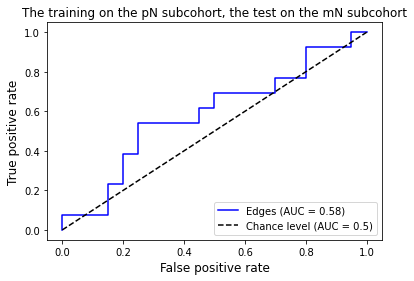

In [50]:
X_train, X_test, y_train, y_test = edges_input.loc[:,common_edges], edges_mN_input.loc[:,common_edges], \
                                    dfcl["Benefit"], mNcl['Benefit'] 

base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=30)),
    ('logistic_regression', base_model)
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",plot_chance_level=True,name=f"Edges",c="blue")

plt.title('The training on the pN subcohort, the test on the mN subcohort',fontsize=12)
plt.ylabel("True positive rate",fontsize=12)
plt.xlabel("False positive rate",fontsize=12)
plt.savefig(f"external_validation_mN_edges_AUC.svg",dpi=600,bbox_inches='tight')
#plt.show()

print("lr准确率：", pipeline.score(X_test, y_test))
print("lr的其他指标：\n", classification_report(y_test, lr_y_predict, target_names=["CB", "NCB"],zero_division=0.0))


In [ ]:
# gene expr

In [ ]:
geneticmN

In [16]:
from sklearn.metrics import roc_auc_score

In [47]:
X_train, X_test, y_train, y_test = modelinput_expr, modelinput_mN_expr , \
                                    dfcl["Benefit"], mNcl['Benefit'] 

base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

for i in range(1,100,1):
    # Combine feature selection and model into a pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),  
        ('feature_selection', SelectKBest( k=i)),
        ('logistic_regression', base_model)
    ])
    
    # Fit the pipeline on training data
    pipeline.fit(X_train, y_train)
    
    #y_pred = pipeline.predict(X_test)
    y_pred = pipeline.predict_proba(X_test)[:, 1]  
    print(i, roc_auc_score(y_test, y_pred))

    

1 0.48846153846153845
2 0.4115384615384615
3 0.3269230769230769
4 0.35
5 0.40769230769230763
6 0.46923076923076923
7 0.38846153846153847
8 0.3346153846153846
9 0.3423076923076923
10 0.3153846153846154
11 0.3538461538461538
12 0.36153846153846153
13 0.35
14 0.3538461538461538
15 0.39615384615384613
16 0.3807692307692308
17 0.38076923076923075
18 0.4076923076923077
19 0.3923076923076923
20 0.3307692307692307
21 0.3153846153846154
22 0.32692307692307687
23 0.29615384615384616
24 0.33076923076923076
25 0.2615384615384615
26 0.28846153846153844
27 0.3153846153846154
28 0.3846153846153846
29 0.43846153846153846
30 0.43846153846153846
31 0.43076923076923074
32 0.43461538461538457
33 0.43076923076923074
34 0.4230769230769231
35 0.4230769230769231
36 0.43076923076923074
37 0.43076923076923074
38 0.43461538461538457
39 0.43461538461538457
40 0.42692307692307685
41 0.423076923076923
42 0.423076923076923
43 0.423076923076923
44 0.4115384615384615
45 0.4076923076923077
46 0.423076923076923
47 0.380

In [44]:
y_pred[0]

'NCB'

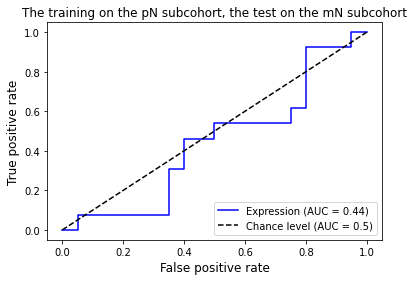

lr准确率： 0.42424242424242425
lr的其他指标：
               precision    recall  f1-score   support

          CB       0.35      0.54      0.42        13
         NCB       0.54      0.35      0.42        20

    accuracy                           0.42        33
   macro avg       0.44      0.44      0.42        33
weighted avg       0.46      0.42      0.42        33



In [51]:
X_train, X_test, y_train, y_test = modelinput_expr, modelinput_mN_expr , \
                                    dfcl["Benefit"], mNcl['Benefit'] 

base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=30)),
    ('logistic_regression', base_model)
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",plot_chance_level=True,name=f"Expression",c="blue")

plt.title('The training on the pN subcohort, the test on the mN subcohort',fontsize=12)
plt.ylabel("True positive rate",fontsize=12)
plt.xlabel("False positive rate",fontsize=12)
#plt.savefig(f"external_validation_mN_expr_AUC.svg",dpi=600,bbox_inches='tight')
plt.show()

print("lr准确率：", pipeline.score(X_test, y_test))
print("lr的其他指标：\n", classification_report(y_test, lr_y_predict, target_names=["CB", "NCB"],zero_division=0.0))


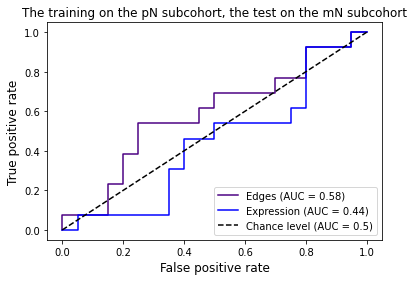

In [20]:
X_train, X_test, y_train, y_test = edges_input.loc[:,common_edges], edges_mN_input.loc[:,common_edges], \
                                    dfcl["Benefit"], mNcl['Benefit'] 

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=30)),
    ('logistic_regression', LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced'))
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",name=f"Edges",c="indigo", ax=plt.gca())



X_train1, X_test1, y_train1, y_test1 = modelinput_expr, modelinput_mN_expr , \
                                    dfcl["Benefit"], mNcl['Benefit'] 


# Combine feature selection and model into a pipeline
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=30)),
    ('logistic_regression', LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced'))
])

# Fit the pipeline on training data
pipeline1.fit(X_train1, y_train1)

lr_y_predict1 = pipeline1.predict(X_test1)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline1,X_test1, y_test1,pos_label="CB",plot_chance_level=True,name=f"Expression",c="blue", ax=plt.gca())

plt.title('The training on the pN subcohort, the test on the mN subcohort',fontsize=12)
plt.ylabel("True positive rate",fontsize=12)
plt.xlabel("False positive rate",fontsize=12)
plt.savefig(f"external_validation_mN_expr_edge_both_included_AUC.svg",dpi=600,bbox_inches='tight')
plt.show()

